# Create 100 foot buffer around buildings

To make sure buffer areas are accurate, transform data to an equal area projection. We will use California Teale-Albers (EPSG: 3310). 

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt

from geopandas import GeoDataFrame

sys.path.append("../utils")

import config

In [6]:
# Import SB buildings dataset
sb_buildings_path = os.path.join(
    config.data_dir, "microsoft_buildings", "sb_buildings.geojson"
)

sb_buildings = gpd.read_file(sb_buildings_path)
sb_buildings = sb_buildings.to_crs("EPSG:3310")

# How many buildings are there in Santa Barbara?
print(f" There are {len(sb_buildings)} buildings in Santa Barbara.")

 There are 130547 buildings in Santa Barbara.


In [7]:
# Import joined inspections and buildings
def import_inspections_buildings_data(year):
    """
    Function to read in inspections data for a given year and convert to Albers CRS.
    """
    inspections_with_buildings = os.path.join(
        config.data_dir,
        "joined_inspections_buildings",
        f"inspections_with_buildings_{year}.geojson",
    )
    inspections_with_buildings = gpd.read_file(inspections_with_buildings).to_crs(
        config.albers_crs
    )
    return inspections_with_buildings


# Read in joined inspections and buildings data for 2019-2023 as separate dataframes
inspections_with_buildings_dict = {}
for year in range(2019, 2024):
    inspections_with_buildings_dict[year] = import_inspections_buildings_data(year)

In [8]:
# Unpack inspections with buildings from dictionary
inspections_with_buildings_2019 = inspections_with_buildings_dict[2019]
inspections_with_buildings_2020 = inspections_with_buildings_dict[2020]
inspections_with_buildings_2021 = inspections_with_buildings_dict[2021]
inspections_with_buildings_2022 = inspections_with_buildings_dict[2022]
inspections_with_buildings_2023 = inspections_with_buildings_dict[2023]

In [9]:
# Read in complete parcels data and convert to Albers CRS
parcels = os.path.join(config.data_dir, "parcel_boundaries", "cbiinputs.gdb")
parcels = gpd.read_file(parcels).to_crs(config.albers_crs)

In [10]:
inspections_with_buildings_2019 = inspections_with_buildings_2019.drop(
    columns=["index_right", "apn"]
)

In [11]:
# Create a copy of parcels with just APN and geometry
parcels_apn = parcels[["apn", "geometry"]].copy()

# Join parcels to inspections
inspections_with_buildings_2019 = gpd.sjoin(
    inspections_with_buildings_2019,
    parcels_apn,
    how="left",
    predicate="intersects",
)

inspections_with_buildings_2019 = inspections_with_buildings_2019.drop(
    columns=["index_right"]
)

### Buffer buildings polygons

Create a 100 foot buffer around all of the building polygons. 100 feet = ~30.48 meters.

In [12]:
# Create a buffer for the inspection and building geometries
buffered_2019 = inspections_with_buildings_2019.copy()
buffered_2019["geometry"] = buffered_2019.geometry.buffer(
    30.48, resolution=50, cap_style=3, join_style=2
).envelope

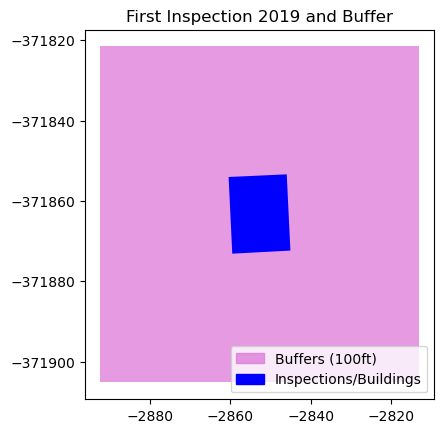

In [13]:
# Create a figure and axis
fig, ax = plt.subplots()

# Create patches for the legend
buffer_patch = plt.Rectangle((0, 0), 1, 1, color="orchid", alpha=0.7)
building_patch = plt.Rectangle((0, 0), 1, 1, color="blue")

# Plot the buffered buildings
buffered_2019.geometry.head(1).plot(
    ax=ax, color="orchid", alpha=0.7, label="Buffers (100ft)"
)

# Plot the buildings
inspections_with_buildings_2019.head(1).plot(
    ax=ax, color="blue", label="Inspections/Buildings"
)

# Add labels and legend
plt.title("First Inspection 2019 and Buffer")
ax.legend(
    [buffer_patch, building_patch],
    ["Buffers (100ft)", "Inspections/Buildings"],
    loc="lower right",
)
plt.show()

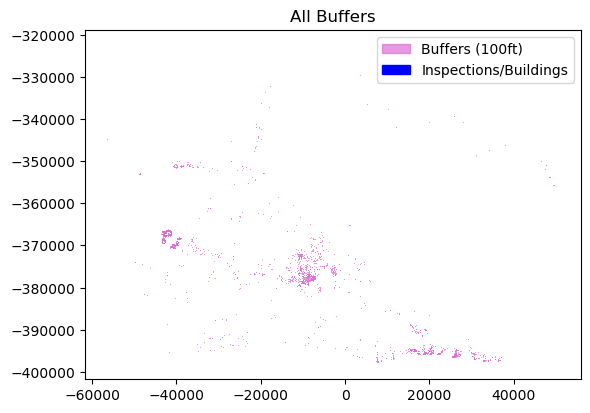

In [14]:
# Create a figure and axis
fig, ax = plt.subplots()

# Plot the buffers
buffered_2019.plot(ax=ax, alpha=0.7, color="orchid")

# Add labels and legend
plt.title("All Buffers")
ax.legend(
    [buffer_patch, building_patch],
    ["Buffers (100ft)", "Inspections/Buildings"],
    loc="upper right",
)
plt.show()

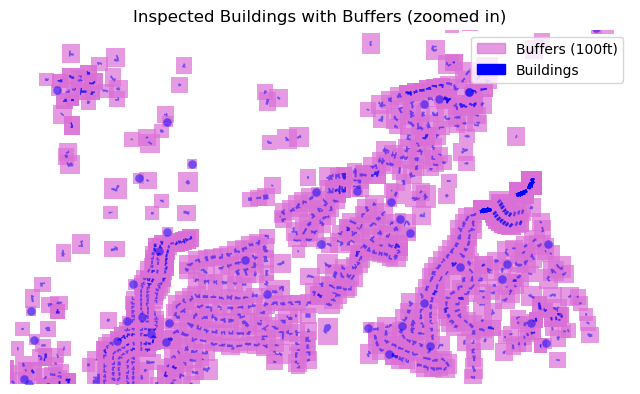

In [15]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the buffers
buffered_2019.plot(ax=ax, alpha=0.7, color="orchid")

# Plot the buildings
inspections_with_buildings_2019.plot(ax=ax, color="blue", linewidth=0.1, alpha=0.5)

# Set axis limits to zoom in
ax.set_xlim(18000, 21500)
ax.set_ylim(-396000, -394000)

# Add labels and legend
plt.title("Inspected Buildings with Buffers (zoomed in)")
ax.legend(
    [buffer_patch, building_patch], ["Buffers (100ft)", "Buildings"], loc="upper right"
)
ax.axis("off")
plt.show()

### Clip building buffers to parcels

The 100 foot buffers for buildings tend to overlap, meaning we need to clip to each parcel since compliance status is determined based on property ownership. 

In [16]:
# Merge the datasets on the 'apn' field
merged = buffered_2019.merge(
    parcels[["apn", "geometry"]], on="apn", how="inner", suffixes=("", "_parcel")
)

# Clip the geometries (this is vectorized and much faster)
merged["geometry"] = merged.apply(
    lambda row: row.geometry.intersection(row.geometry_parcel), axis=1
)

# Drop the parcel geometry column as it's no longer needed
clipped_geometries = merged.drop(columns=["geometry_parcel"])


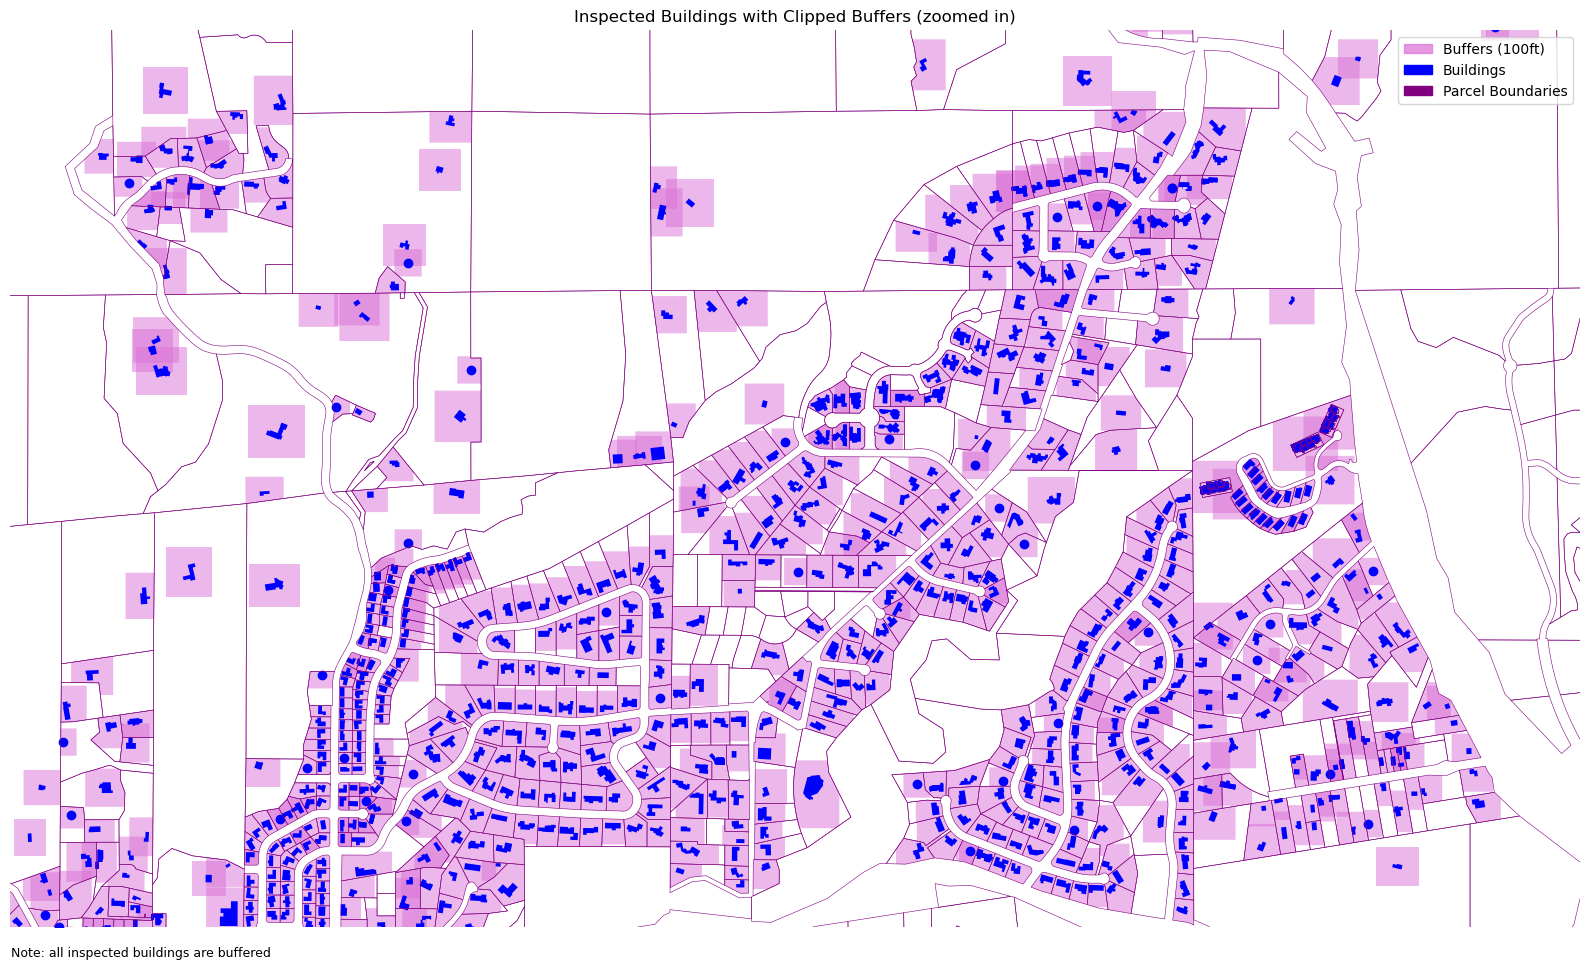

In [17]:
# Plot to confirm the largest building per parcel was kept
fig, ax = plt.subplots(figsize=(16, 12))

# Plot the buffers
clipped_geometries.plot(ax=ax, alpha=0.5, color="orchid")

# Plot the buildings
inspections_with_buildings_2019.plot(ax=ax, color="blue")

# Plot the parcel boundaries
parcels.boundary.plot(ax=ax, color="purple", linewidth=0.4)

# Set axis limits to zoom in
ax.set_xlim(18000, 21500)
ax.set_ylim(-396000, -394000)

# Add labels and legend
parcels_patch = plt.Rectangle((0, 0), 1, 1, color="purple")

plt.title("Inspected Buildings with Clipped Buffers (zoomed in)")
plt.figtext(
    0.01,
    0.10,
    "Note: all inspected buildings are buffered",
    fontsize=9,
)
ax.legend(
    [buffer_patch, building_patch, parcels_patch],
    ["Buffers (100ft)", "Buildings", "Parcel Boundaries"],
    loc="upper right",
)
ax.axis("off")
plt.tight_layout()
plt.subplots_adjust(bottom=0.01)
plt.show()

## Create buffers for all years and save to file

Located in `data/buffer_geometries`

In [18]:
def buffer_buildings(year):
    """
    Function to buffer buildings in a given year.
    """
    # Read in inspections with buildings data for the given year
    inspections_with_buildings = inspections_with_buildings_dict[year]
    
    inspections_with_buildings = inspections_with_buildings.drop(
        columns=["index_right", "apn"]
    )

    # Join parcels to inspections
    inspections_with_buildings = gpd.sjoin(
        inspections_with_buildings,
        parcels_apn,
        how="left",
        predicate="intersects",
    )

    inspections_with_buildings = inspections_with_buildings.drop(
        columns=["index_right"]
    )

    # Create a buffer for the inspection and building geometries
    buffered = inspections_with_buildings.copy()

    buffered["geometry"] = buffered.geometry.buffer(
        30.48, resolution=50, cap_style=3, join_style=2
    ).envelope

    # Merge the datasets on the 'apn' field
    merged = buffered.merge(
        parcels[["apn", "geometry"]], on="apn", how="inner", suffixes=("", "_parcel")
    )

    # Clip the geometries (this is vectorized and much faster)
    merged["geometry"] = merged.apply(
        lambda row: row.geometry.intersection(row.geometry_parcel), axis=1
    )

    # Drop the parcel geometry column as it's no longer needed
    clipped_geometries = merged.drop(columns=["geometry_parcel"])
    
    return clipped_geometries

# Read in joined inspections and buildings data for 2019-2023 as separate dataframes
clipped_geometries_dict = {}
for year in range(2019, 2024):
    clipped_geometries_dict[year] = buffer_buildings(year)

In [19]:
# Save the processed datasets
for year, data in clipped_geometries_dict.items():
    output_path = os.path.join(
        config.data_dir,
        "buffer_geometries",
        f"buffer_geometries_{year}.geojson",
    )
    data.to_file(output_path, driver="GeoJSON")